In [22]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn import mixture
from sklearn.cluster import DBSCAN
from copy import copy

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from src import render
from src import localise as _localise
from src import postprocess as _postprocess

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

from src import FiducialDetection

FD = FiducialDetection.FiducialDetector()


import types

import DriftCorrectionFunctions as DCF
from src.LinkingFunctions import link_localisations


H_F = HelperFunctions.Helper_Functions()

/tmp/ipykernel_1114770/535978356.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [38]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/AlphaSynPAINT/20260205_alpha_syn_NR_PLL/1nM_NR_10uM_asyn72h_2p5AuNP/50ms_70p_515_LP515_bp650_200_4"
image_files = H_F.file_search(image_folder, ".tif", "")

In [39]:
localisation_files = H_F.file_search(image_folder, ".h5", "")
metadata_files = H_F.file_search(image_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [40]:
loc_data = pd.read_hdf(localisation_files[0])

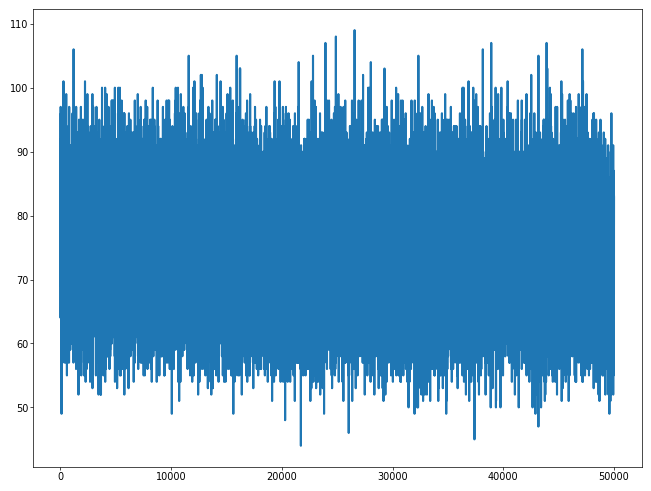

In [42]:
plt.plot(loc_data.groupby('frame').count()['xc'])

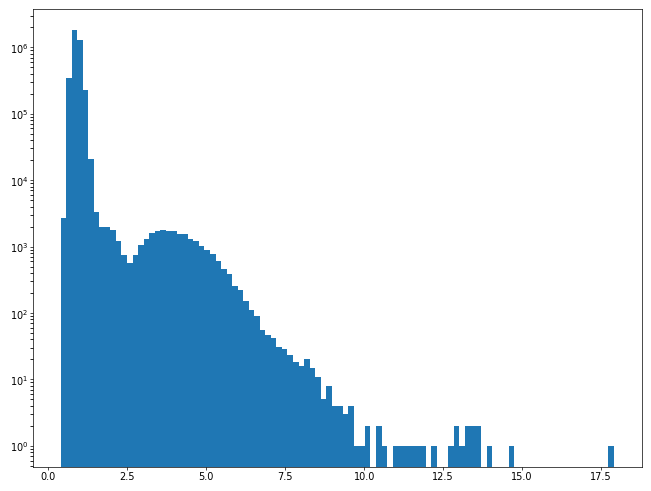

In [43]:
plt.hist(loc_data['chi_sqr'], 100);
plt.yscale('log')
plt.show()

In [44]:
loc_data = loc_data[loc_data["xc_err"] < 100/69]
loc_data = loc_data[loc_data["yc_err"] < 100/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 100/69]
loc_data = loc_data[loc_data["s_y_err"] < 100/69]

loc_data = loc_data[(loc_data["s_x"] > 75/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 75/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.05]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

#loc_data = loc_data[~((loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100))]


#loc_data = loc_data[loc_data["photons"] < 100000]
loc_data = loc_data[loc_data["photons"] > 200]


loc_data = loc_data[loc_data["chi_sqr"] < 4]

In [45]:
len(loc_data)

819566

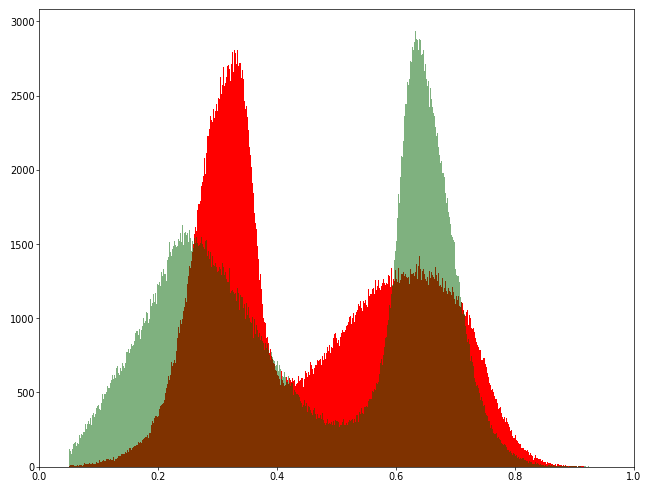

In [46]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

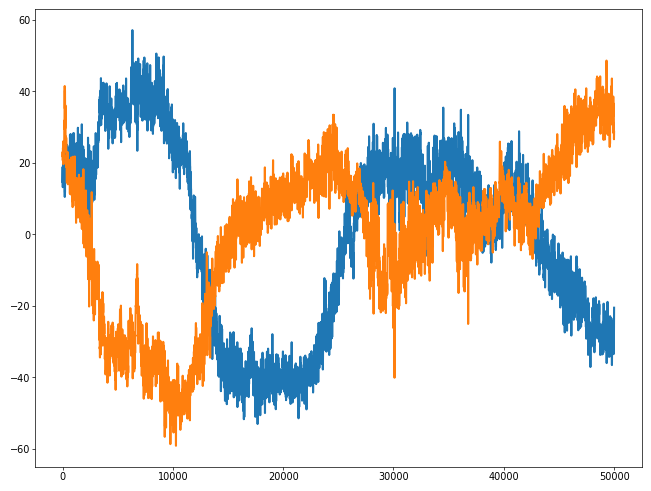

In [49]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=10,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [50]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

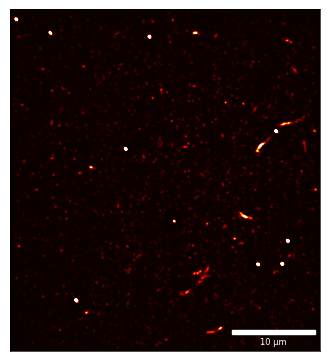

In [51]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), cbar='off')

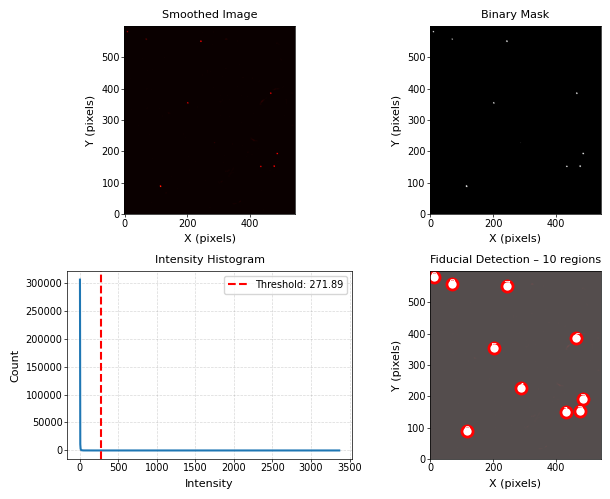

In [56]:
region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=image,
      histogram_bins=821,
      threshold_percentile=99.95,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

Memory optimisation: Freed intermediate arrays after region processing          3.37it/s]


/home/jsb92/Documents/pyBayerSMLM/src/DriftPlotting.py:668: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


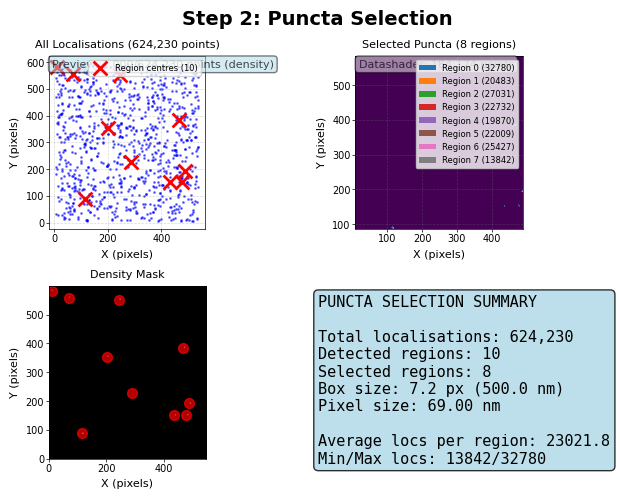

In [58]:
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=linked.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.25*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [59]:
linked_fremoved = FD.remove_puncta_locs(linked.to_records(index=False), selected_puncta)
linked_fremoved = pd.DataFrame(linked_fremoved)

remove_puncta_locs: removed 184,174 localisations (29.5% of 624,230 total)


In [60]:
IO._write_h5_database(df=linked_fremoved, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted_Linked_FiducialsRemoved.h5', normalise_photons=False)

In [ ]:
linked_fremoved = pd.read_hdf(localisation_files[1])

Step 1/5: Rendering super-resolved image...
Step 2/5: Applying percentile thresholding...
Step 3/5: Detecting connected regions...
Step 4/5: Filtering aggregates by size and localisation count...


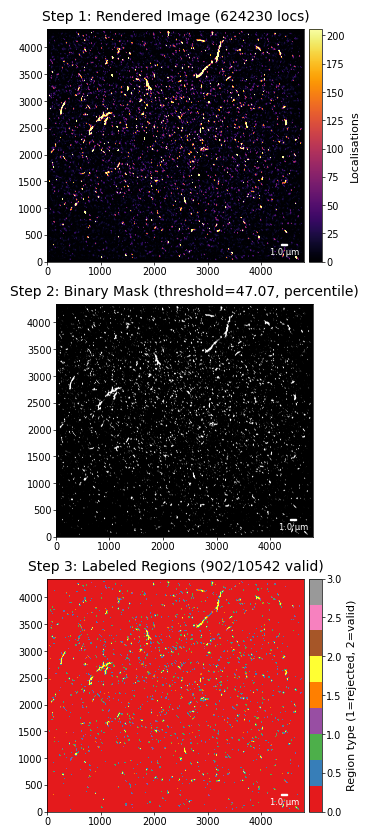

Found 902 valid aggregates (from 10542 total regions)
Step 5/5: Extracting localisations and computing statistics...
✓ Complete! Extracted 402668 localisations in 902 aggregates                    0.42it/s]


In [67]:
# Define parameters
MIN_AREA_NM2 = 5000.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 50      # Minimum localisations per cluster
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


file = localisation_files[1]
# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
cluster_locs, per_cluster_stats = _postprocess.segment_locs_by_rendered_image(
    linked,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='percentile',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
cluster_locs = cluster_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_cluster_stats = per_cluster_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Save results (same file names as before)
IO._write_h5_database(
    df=cluster_locs,
    filepath=file.split('.h5')[0] + '_clusteredlocs.h5',
    append=False,
    normalise_photons=False
)

IO._write_h5_database(
    df=per_cluster_stats,
    filepath=file.split('.h5')[0] + '_averagedoverclusters.h5',
    append=False,
    normalise_photons=False
)

In [68]:
oversampling = 8

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(cluster_locs['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=cluster_locs.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

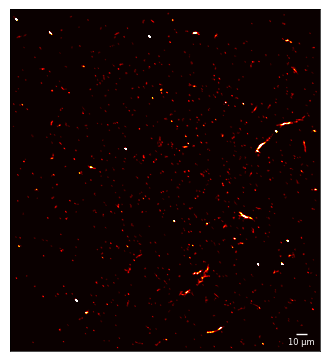

In [69]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), cbar='off')

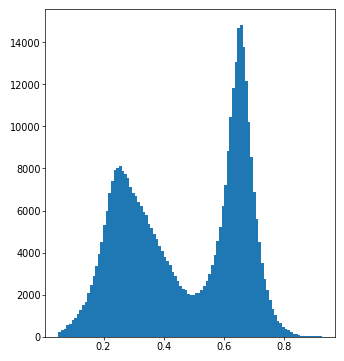

In [71]:
plt.hist(cluster_locs['A_G'], 100);
plt.show()

In [72]:
# ============================================================================
# Channel Unmixing Test
# ============================================================================

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

Channel Unmixing
Input: 402668 localizations
Channels: 2
Features: ['A_R', 'A_G']

Feature matrix: (402668, 2)
Feature ranges:
  A_R: [0.051, 0.925], mean=0.465
  A_G: [0.050, 0.923], mean=0.467

Finding initial channel means (method: histogram_peaks)...
Initial means:
  Channel 0: A_R=0.304, A_G=0.653
  Channel 1: A_R=0.689, A_G=0.251

Estimating initial covariances from core regions (conservative)...
  Channel 0: det(cov)=0.000000, σ1=0.007, σ2=0.022
  Channel 1: det(cov)=0.000000, σ1=0.012, σ2=0.039



/home/jsb92/Documents/pyBayerSMLM/notebooks/asyn_aggregates/../../src/SM_extractionfunctions.py:3844: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Make room for colorbar


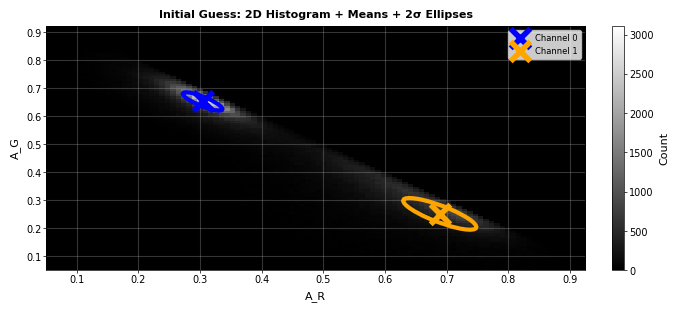

Fitting GMM (method: fixed, covariance: full)...
  Error columns available (mean errors: [ 0.00273194  0.00218378])
Using fixed initial guess (no EM refinement)
GMM fitting: converged
Fitted means:
  Channel 0: A_R=0.304, A_G=0.653 (weight: 52.8%)
  Channel 1: A_R=0.689, A_G=0.251 (weight: 47.2%)

Calculating posterior probabilities and assignments...
Calculating analytical FPR to determine confidence threshold (target: 0.050)...
Analytical accuracy: 1.000
Confusion matrix:
[[ 1.  0.]
 [ 0.  1.]]

Setting confidence threshold to 0.975 (from FPR=0.050)
Applying Mahalanobis distance outlier rejection...
  Outliers detected: 188564 (46.83%, threshold=3.72)

Unmixing Complete
Assignments:
  Channel 0: 108,679 (27.0%)
  Channel 1: 103,426 (25.7%)
  Unassigned: 190,563 (47.3%)



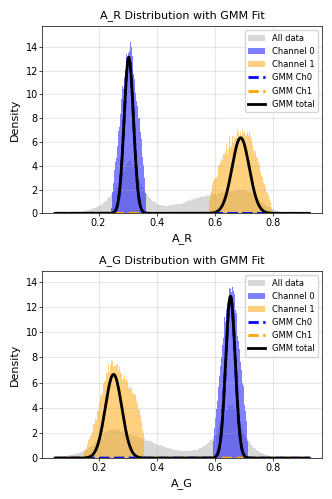

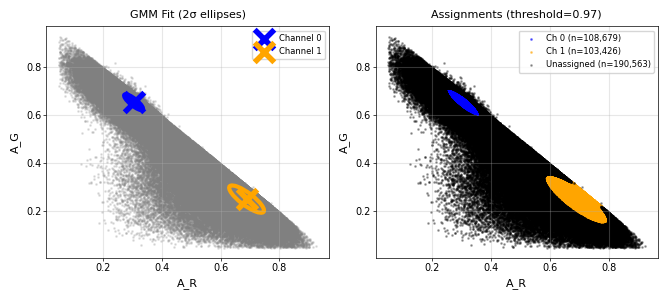

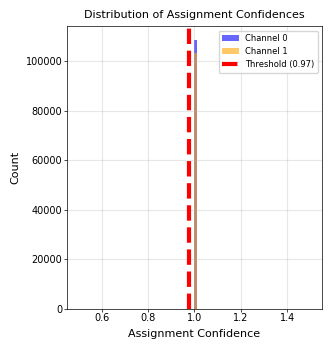

/home/jsb92/Documents/pyBayerSMLM/notebooks/asyn_aggregates/../../src/SM_extractionfunctions.py:4023: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Make room for colorbar


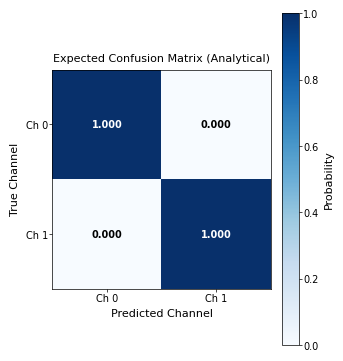

In [74]:
# Test channel unmixing on the filtered loc_data
# This data has ATTO655 (red) and Cy3B (green)

assigned_locs, metadata = SM_E.unmix_channels(
    cluster_locs,
    n_channels=2,
    channels_to_use=['A_R', 'A_G'],
    confidence_threshold=0.95,  # Start with 95% confidence
    false_positive_rate=0.05,
    initial_guess_method='histogram_peaks',
    gmm_fit_method='fixed',
    covariance_type='full',
    outlier_rejection='mahalanobis',
    mestimator_type='tukey',
    initial_guess_percentile=50,
    initial_guess_scale=0.5,
    verbose=True,
    plot_results=True
)

In [75]:
channel_1 = assigned_locs[assigned_locs['channel'] == 1]
channel_1 = channel_1.reset_index()
channel_0 = assigned_locs[assigned_locs['channel'] == 0]
channel_0 = channel_0.reset_index()

In [78]:
IO._write_h5_database(
    df=channel_1,
    filepath=file.split('.h5')[0] + '_clusteredlocs_channel1.h5',
    append=False,
    normalise_photons=False
)

In [24]:
aggregate_loc_files = H_F.file_search(image_folder, "_aggregatelocs.h5", "")
aggregate_averaged_loc_files = H_F.file_search(image_folder, "_averagedoveraggregates.h5", "")
metadata_files = H_F.file_search(image_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [79]:
import NileRedFunctions
import SpectralFunctions

# Initialize
nrf = NileRedFunctions.NileRed_Functions()

# Define optical setup
filters = [
  "semrock-ff01-650-200",
  "semrock-di03-r514-t1-25x36",
  "semrock-ff01-515-lp",
]

# Setup camera parameters
sf = SpectralFunctions.Spectral_Funcs()
R, G, B, wavelength = sf.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_params = {
  'pixel_QYs': pixel_QYs,
  'wavelength': wavelength,
}

analysis_files = H_F.file_search(image_folder, "_clusteredlocs_channel1.h5", "")

MIN_LOCS_ANALYSIS = 10      # Minimum localisations per wl fit

for file in analysis_files:
    # Fit wavelengths from HDF5 file
    # should now average and use average as initial guess
    df_with_wavelengths, grid_info = nrf.fit_wavelengths_pixelated(
      h5_path=file,
      filter_names=filters,
      camera_parameters=camera_params,
      output_path=file,
      min_localisations=MIN_LOCS_ANALYSIS,
      pixel_size_nm=50,
      aggregate_id_column='cluster_id',
    )


Pixelated Nile Red Wavelength Fitting
Input file: /scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/AlphaSynPAINT/20260205_alpha_syn_NR_PLL/1nM_NR_10uM_asyn72h_2p5AuNP/50ms_70p_515_LP515_bp650_200_4/Localisations_averagedoverclusters_clusteredlocs_channel1.h5
Grid pixel size: 50 nm
Min localisations per pixel: 10
Wavelength bounds: 500.0-750.0 nm

Loaded 103426 localisations
Optical system configured with 3 filters
Using photon counts for SNR-based error inflation

--- Fitting aggregate-level wavelengths ---
Grouping by 'cluster_id'...
Found 890 aggregates
Aggregate fitting: 890 tasks with 28 workers...
  Aggregate fitting progress: 890/890 (100.0%) - 358.5 fits/s
  Aggregate fitting complete: 890/890 in 2.5 s
  Aggregate wavelength range: 585.2 - 663.5 nm
  Median: 596.6 nm
  Fitted: 890/890 aggregates
Grid dimensions: 738 x 814 pixels (36900 x 40700 nm)

Pixel groups: 16655 total
  Fitting: 2388 pixels (>= 10 localisations)
  Skipped: 14267 pixels (< 10 localisations)
  Locs/

In [80]:
averaged = df_with_wavelengths.groupby('pixel_ix', as_index=False).agg(                                                                                                                                                                                                         
      xc       = ('xc',      'mean'),                                                                                                                                                                                                                          
      yc       = ('yc',      'mean'),                                                                                                                                                                                                                            
      A_R      = ('A_R',     'mean'),                                                                                                                                                                                                                            
      A_G      = ('A_G',     'mean'),                                                                                                                                                                                                                            
      A_B      = ('A_B',     'mean'),                                                                                                                                                                                                                            
      photons  = ('photons', 'sum'),  
      wl_pixel = ('wl_pixel', 'mean'),
      n_locs   = ('frame',   'count'),   # number of localisations per pixel                                                                                                                                                                                     
  )
averaged['log_photons'] = np.log10(averaged['photons'])


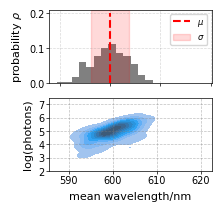

In [85]:
import seaborn as sns

fig, axs = plotter.one_column_plot(width=2.1, height=2, npanels=2, ratios=[1,1])

axs[0] = plotter.histogram_plot(axs[0], averaged['wl_pixel'], bins=np.histogram_bin_edges(averaged['wl_pixel'], 'scott'),
                               xaxislabel='')
mean=np.mean(averaged['wl_pixel'])
axs[0].vlines(x=mean, ymin=0, ymax=0.2, ls='--', color='red', label=r'$\mu$')

std=np.std(averaged['wl_pixel'])
axs[0].axvspan(mean - std, mean + std, alpha=0.15, color='red', label=r'$\sigma$')

axs[0].set_ylabel(r'probability $\rho$')
axs[0].set_xticklabels([])
axs[0].legend(fontsize=6)
axs[1].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')

sns.kdeplot(data=averaged, x="wl_pixel", y="log_photons", ax=axs[1], fill=True)
axs[1].set_xlabel('mean wavelength/nm')
axs[1].set_ylabel('log(photons)')
axs[1].set_ylim([2, 7.5])
axs[1].set_yticks([2, 3, 4, 5, 6, 7])

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "AlphaSyn_Analysis_Wavelength.svg"), dpi=600, format="svg")
plt.show()

In [96]:
oversampling=8

n_locs, image_FOV, image_FOV_colour = render.render(
    locs=df_with_wavelengths.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(df_with_wavelengths['yc']), np.max(df_with_wavelengths['xc']))),
    blur_method="gaussian_colour",
    cparam='wl_pixel',
    c_min=np.percentile(averaged['wl_pixel'], 0.1),
    c_max=np.percentile(averaged['wl_pixel'], 99.5),
)

In [97]:
from matplotlib import colors as mcolors
from copy import copy

In [98]:
image_total = copy(image_FOV)
vmax = np.percentile(image_total, 99.5)  # ignore empty pixels
vmin = np.percentile(image_total, 1)                                                                                                                                                                                                                                                  

new_brightness = np.clip((image_total - vmin) / (vmax - vmin), 0, 1)                                                                                                                                                                                           
                                                        
hsv = mcolors.rgb_to_hsv(image_FOV_colour)                                                                                                                                                                                                                         
hsv[..., 2] = new_brightness                              
image_adjusted = mcolors.hsv_to_rgb(hsv)

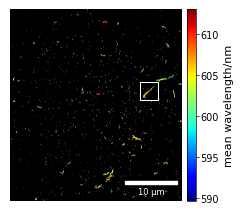

In [106]:
fig, axs = plotter.two_column_plot(height=2, width=2.25)

cut = image_adjusted[500:, 500:, :]
axs = plotter.colour_image_plot(axs, cut, cbar="on", cbarlabel=r'mean wavelength/nm', cmap="jet",
                            c_min=np.percentile(averaged['wl_pixel'], 0.1),
                            c_max=np.percentile(averaged['wl_pixel'], 99.5),
                            pixelsize=69/oversampling)

import matplotlib.patches as patches

rect = patches.Rectangle(
    ((360 * oversampling), (280 * oversampling)),
    50 * oversampling,
    50 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "Image_AlphaSyn_Wavelength.svg"), dpi=600, format="svg")
plt.show()

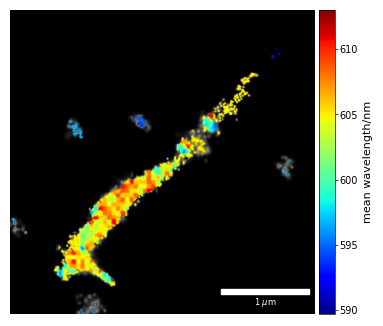

In [107]:
fig, axs = plotter.one_column_plot()

cut = image_adjusted[500:, 500:, :]
data = cut[
        int(280 * oversampling) : int(280 * oversampling) + int(50 * oversampling),
        int(360) * oversampling : int(360) * oversampling + int(50 * oversampling),
        :
    ]

axs = plotter.colour_image_plot(
    axs=axs,
    data=data,
    cbar='on',
    cbarlabel=r'mean wavelength/nm', 
    cmap="jet",
    c_min=np.percentile(averaged['wl_pixel'], 0.1),
    c_max=np.percentile(averaged['wl_pixel'], 99.5),
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "AlphaSyn_Zoomin_Colour.svg"), dpi=600, format="svg")
plt.show()